<a href="https://colab.research.google.com/github/UCREL/pymusas_notebook/blob/main/PyMUSAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Pre-requisite: HuggingFace user access token

In this tutorial we are going to download data from [HuggingFace](https://huggingface.co/) and potentially in the "extra" sections download models from HuggingFace, because of this it is **better but not required** to be logged into HuggingFace via a *user access token* with **read only** permissions so that it lowers the chance of being blocked from downloading said data due to rate limits that are in place for unknown users. The number of requests made using this notebook with your HuggingFace account will not exceed any API limit from a **free HuggingFace account**.

If you have a [HuggingFace](https://huggingface.co/) account (which are free (paid tiers are available but not required for this notebook)) please do consider creating a user access token following these instructions (it is also easy to sign up for users that do not have a HuggingFace account).

To get a HuggingFace user access token go to your [settings access token web page](https://huggingface.co/settings/tokens) and create a new "Fine-grained" token with "Read access to contents of all repos under your personal namespace" permission only, name it anything you want, i.e. "USS-PyMUSAS-2026", copy the access token and follow either the `Running on Google Colab` or `Running locally` guide below:

**After you have finished with this tutorial you can delete this user access token.**

**NEVER share this token with anyone and do not store it in a GitHub repository**

### Running on Google Colab:


Google Colab specific:

Google Colab has a built-in "Secrets" feature that mimics environment variables perfectly.

1. Click the Key icon (Secrets) on the left sidebar.
2. Add a new secret with the Name: HF_TOKEN.
3. Paste your Hugging Face access token into the Value field.
4. Toggle the switch to grant Notebook access.
5. Run this code in your notebook:

In [57]:
try:
    import os
    from google.colab import userdata
    # Colab requires this step to inject the secret into the environment
    os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
    # Now os.getenv works perfectly
    hf_token = os.getenv("HF_TOKEN")
except ImportError:
    print(f"It does not look like you are using Google Colab try the Running locally guide instead")

It does not look like you are using Google Colab try the Running locally guide instead


### Running locally

If you are running the notebook on your own computer (not on Google colab), create a `.env` file in the same directory as this notebook and add the following to `.env`:
``` bash
HF_TOKEN=PASTE_YOUR_TOKEN_HERE
```
Replace `PASTE_YOUR_TOKEN_HERE` with the HuggingFace user access token you have copied.

In [1]:
! pip install --index-url https://download.pytorch.org/whl/cpu torch
! pip install 'pymusas[neural]' spacy rich python-dotenv huggingface_hub

from pathlib import Path

from dotenv import load_dotenv

if Path(".env").exists():
    # Reads any environment variables stored in ".env" and sets them as environment
    # variables. This is used to load a local HuggingFace access token if it exists
    load_dotenv(".env")

def is_logged_into_huggingface() -> bool:
    from huggingface_hub import whoami
    from huggingface_hub.errors import HfHubHTTPError
    from huggingface_hub.utils import LocalTokenNotFoundError

    try:
        user_info = whoami()
        print(f"Logged in as: {user_info['name']}")
        return True
    except LocalTokenNotFoundError:
        print("❌ You are not logged in and no token was found on this system.")
    except HfHubHTTPError:
        print("❌ The token you provided is invalid, expired, or has been revoked.")
    return False

Looking in indexes: https://download.pytorch.org/whl/cpu


In [2]:
import subprocess
import sys
from enum import Enum

from rich import print as rprint
import spacy

In [3]:
# This contains language specific resources

class Languages(str, Enum):
    zh = "Chinese"
    da = "Danish"
    nl = "Dutch"
    en = "English"
    fi = "Finnish"
    it = "Italian"
    pt = "Portuguese"
    es = "Spanish"
    fr = "French"

LANGUAGE_2_PYMUSAS_RULE_MODEL: dict[Languages, str] = {
    Languages.zh: "cmn_dual_upos2usas_contextual_none",
    Languages.da: "da_dual_none_contextual_none",
    Languages.nl: "nl_single_upos2usas_contextual_none",
    Languages.en: "en_dual_none_contextual_none",
    Languages.fi: "fi_single_upos2usas_contextual_none",
    Languages.fr: "fr_single_upos2usas_contextual_none",
    Languages.it: "it_dual_upos2usas_contextual_none",
    Languages.pt: "pt_dual_upos2usas_contextual_none",
    Languages.es: "es_dual_upos2usas_contextual_none",
}

class SpacyModel(str, Enum):
    zh_md = "zh_core_web_md"
    da_md = "da_core_news_md"
    nl_md = "nl_core_news_md"
    en_md  = "en_core_web_md"
    fi_md = "fi_core_news_md"
    fr_md = "fr_core_news_md"
    it_md = "it_core_news_md"
    pt_md = "pt_core_news_md"
    es_md = "es_core_news_md"
    
    

LANGUAGE_2_SPACY_MODEL: dict[Languages, SpacyModel] = {
    Languages.zh: SpacyModel.zh_md,
    Languages.da: SpacyModel.da_md,
    Languages.nl: SpacyModel.nl_md,
    Languages.en: SpacyModel.en_md,
    Languages.fi: SpacyModel.fi_md,
    Languages.fr: SpacyModel.fr_md,
    Languages.it: SpacyModel.it_md,
    Languages.pt: SpacyModel.pt_md,
    Languages.es: SpacyModel.es_md
}

PYMUSAS_SPACY_MODEL_2_URL: dict[str, str] = {
    "cmn_dual_upos2usas_contextual_none": "https://github.com/UCREL/pymusas-models/releases/download/cmn_dual_upos2usas_contextual_none-0.4.0/cmn_dual_upos2usas_contextual_none-0.4.0-py3-none-any.whl",
    "da_dual_none_contextual_none": "https://github.com/UCREL/pymusas-models/releases/download/da_dual_none_contextual_none-0.4.1/da_dual_none_contextual_none-0.4.1-py3-none-any.whl",
    "nl_single_upos2usas_contextual_none": "https://github.com/UCREL/pymusas-models/releases/download/nl_single_upos2usas_contextual_none-0.4.0/nl_single_upos2usas_contextual_none-0.4.0-py3-none-any.whl",
    "en_dual_none_contextual_none": "https://github.com/UCREL/pymusas-models/releases/download/en_dual_none_contextual_none-0.4.0/en_dual_none_contextual_none-0.4.0-py3-none-any.whl",
    "fi_single_upos2usas_contextual_none": "https://github.com/UCREL/pymusas-models/releases/download/fi_single_upos2usas_contextual_none-0.4.0/fi_single_upos2usas_contextual_none-0.4.0-py3-none-any.whl",
    "fr_single_upos2usas_contextual_none": "https://github.com/UCREL/pymusas-models/releases/download/fr_single_upos2usas_contextual_none-0.4.0/fr_single_upos2usas_contextual_none-0.4.0-py3-none-any.whl",
    "it_dual_upos2usas_contextual_none": "https://github.com/UCREL/pymusas-models/releases/download/it_dual_upos2usas_contextual_none-0.4.0/it_dual_upos2usas_contextual_none-0.4.0-py3-none-any.whl",
    "pt_dual_upos2usas_contextual_none": "https://github.com/UCREL/pymusas-models/releases/download/pt_dual_upos2usas_contextual_none-0.4.0/pt_dual_upos2usas_contextual_none-0.4.0-py3-none-any.whl",
    "es_dual_upos2usas_contextual_none": "https://github.com/UCREL/pymusas-models/releases/download/es_dual_upos2usas_contextual_none-0.4.0/es_dual_upos2usas_contextual_none-0.4.0-py3-none-any.whl",
}

SPACY_MODEL_2_URL: dict[str, str] = {
    "zh_core_web_md": "https://github.com/explosion/spacy-models/releases/download/zh_core_web_md-3.8.0/zh_core_web_md-3.8.0-py3-none-any.whl",
    "da_core_news_md": "https://github.com/explosion/spacy-models/releases/download/da_core_news_md-3.8.0/da_core_news_md-3.8.0-py3-none-any.whl",
    "nl_core_news_md": "https://github.com/explosion/spacy-models/releases/download/nl_core_news_md-3.8.0/nl_core_news_md-3.8.0-py3-none-any.whl",
    "en_core_web_md": "https://github.com/explosion/spacy-models/releases/download/en_core_web_md-3.8.0/en_core_web_md-3.8.0-py3-none-any.whl",
    "fi_core_news_md": "https://github.com/explosion/spacy-models/releases/download/fi_core_news_md-3.8.0/fi_core_news_md-3.8.0-py3-none-any.whl",
    "fr_core_news_md": "https://github.com/explosion/spacy-models/releases/download/fr_core_news_md-3.8.0/fr_core_news_md-3.8.0-py3-none-any.whl",
    "it_core_news_md": "https://github.com/explosion/spacy-models/releases/download/it_core_news_md-3.8.0/it_core_news_md-3.8.0-py3-none-any.whl",
    "pt_core_news_md": "https://github.com/explosion/spacy-models/releases/download/pt_core_news_md-3.8.0/pt_core_news_md-3.8.0-py3-none-any.whl",
    "es_core_news_md": "https://github.com/explosion/spacy-models/releases/download/es_core_news_md-3.8.0/es_core_news_md-3.8.0-py3-none-any.whl"
}

# All examples come from Wikipedia articles and all except for Finnish and Spanish 
# come from the Wikipedia article about the Nile River. The Finnish and Spanish
# examples come from Wikipedia articles about the financial institutes that are banks (Pankki)
# and the country The Netherlands (Países Bajos) respectively.
SINGLE_SENTENCE_EXAMPLE: dict[Languages, str] = {
    Languages.zh: "尼罗河 是一条流經非洲東部與北部的河流，與中非地區的剛果河、非洲南部的赞比西河以及西非地区的尼日尔河並列非洲最大的四個河流系統。",
    Languages.da: "Mindst 65% af Nilens vand kommer fra Den Blå Nil, som udspringer ved Tanasøen i Etiopien.",
    Languages.nl: "De Nijl is met een lengte van 5499 tot 6695 km de langste of de op een na langste rivier van de wereld.",
    Languages.en: "The Nile is a major north-flowing river in Northeastern Africa.",
    Languages.fi: "Pankki on instituutio, joka tarjoaa finanssipalveluita, erityisesti maksuliikenteen hoitoa ja luotonantoa.",
    Languages.fr: "Le Nil est un fleuve d'Afrique. Avec une longueur d'environ 6 700 km, c'est avec le fleuve Amazone, le plus long fleuve du monde.",
    Languages.it: "Il Nilo è un fiume africano lungo 6.852 km che attraversa otto stati dell'Africa. Tradizionalmente considerato il fiume più lungo del mondo, contende il primato della lunghezza al Rio delle Amazzoni.",
    Languages.pt: "Todos estes estudos levam a que o comprimento de ambos os rios permaneça em aberto, continuando por isso o debate e como tal, continuando-se a considerar o Nilo como o rio mais longo.",
    Languages.es: "Los Países Bajos son un país soberano ubicado al noreste de la Europa continental y el país constituyente más grande de los cuatro que, junto con las islas de Aruba, Curazao y San Martín, forman el Reino de los Países Bajos.",
}

# Determines if the language can identify MWEs using the Rule Based system
LANGUAGE_MWE_IDENTIFICATION: dict[Languages, bool] = {
    Languages.zh: True,
    Languages.da: True,
    Languages.nl: False,
    Languages.en: True,
    Languages.fi: False,
    Languages.fr: False,
    Languages.it: True,
    Languages.pt: True,
    Languages.es: True,
}

WIKIPEDIA_LANGUAGE_CODE: dict[Languages, str] = {
    Languages.zh: "zh",
    Languages.da: "da",
    Languages.nl: "nl",
    Languages.en: "en",
    Languages.fi: "fi",
    Languages.fr: "fr",
    Languages.it: "it",
    Languages.pt: "pt",
    Languages.es: "es",
}




# PyMUSAS Introduction - UCREL Summer School 2026

In this tutorial we show how to:
1. Load a Rule Based semantic tagger.
2. Semantically tag a single sentence.
3. Semantically tagging a large dataset using datasets from HuggingFace.
4. Comparing two semantically tagged dataset through visualisation and a keyness metric.
5. Extension work: at the you can explore the Hybrid and Neural tagger through the tutorials on the [PyMUSAS documentation website](https://ucrel.github.io/pymusas/)


Throughout this guide you have a choice of what language you would like to learn to tag text in, the languages you can choose from are:

In [4]:
print("\n".join([f"{language.name} - {language.value}" for language in Languages]))

zh - Chinese
da - Danish
nl - Dutch
en - English
fi - Finnish
it - Italian
pt - Portuguese
es - Spanish
fr - French


To choose a language simply assign the variable `LANGUAGE` to the given language code of choice:

In [ ]:
LANGUAGE = Languages.en # English language is the default language

To start with we are going to show you how to use the [Rule Based Tagger](https://ucrel.github.io/pymusas/usage/how_to/tag_text_with/rule_based_tagger) as it is the quickest tagger and later on we will show you how to use the [Hybrid tagger](https://ucrel.github.io/pymusas/usage/how_to/tag_text_with/hybrid_tagger) and then [Neural Tagger](https://ucrel.github.io/pymusas/usage/how_to/tag_text_with/neural_tagger) for languages that the Rule Based and thus Hybrid tagger do not support.

> 📝 **Note:** We do support more languages for Rule/Hybrid taggers, but for ease of learning we are only focusing on this subset of languages, for a guide on all languages that PyMUSAS supports for Rule/Hybrid tagger see: [https://ucrel.github.io/pymusas/usage/how_to/tag_text_with/rule_based_tagger](https://ucrel.github.io/pymusas/usage/how_to/tag_text_with/rule_based_tagger)

### Downloading the relevant models

For all taggers, including the Neural tagger, we require a **tokenizer**, but the Rule Based tagger also uses the following information;
* Lemma/Stem (spaCy does not support this for; `Chinese`)
* Part Of Speech (POS)

Neither of these linguistic properties are required by the tagger but it does make it more accurate.

Therefore we are going to download the spaCy model that will provide us with our **pre-processing pipeline**; tokenizer, lemmatizer, and POS tagger and then download the **PyMUSAS semantic tagging model**. In this guide we use the **Medium size spaCy models** as they are a good trade off between speed and accuracy but you can use any spaCy model size, i.e. small, large, transformer.

> 📝 **Note:** in this tutorial we are using spaCy models to provide the pre-processing pipeline; tokenization, lemma, and POS tags but you can use other model providers like [Stanza](https://stanfordnlp.github.io/stanza/) and some of the languages we do not demonstrate here, like [Welsh](https://ucrel.github.io/pymusas/usage/how_to/tag_text_with/rule_based_tagger), do use other model providers.

In [6]:
def pip_install_model(wheel_url: str, spacy_model_name: str | None = None) -> None:
    """Install a model package from a wheel URL via pip.

    If `spacy_model_name` is provided and is already installed as a spaCy
    package, installation is skipped.

    Args:
        wheel_url: URL or path to the wheel file to install via pip.
        spacy_model_name: Name of the spaCy model package to check before
            installing. If None, no pre-check is performed and the wheel
            is always installed.

    Returns:
        None. Prints status messages indicating whether the model was
        already installed, installed successfully, or failed to install.
    """
    rprint(f"Pip installing the following wheel: {wheel_url}")
    
    if spacy_model_name is not None and spacy.util.is_package(spacy_model_name):
        rprint(f"[green]✓ {spacy_model_name} is already installed[/green]")
        return
    
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", wheel_url],
        capture_output=True,
        text=True
    )
    if result.returncode == 0:
        rprint(f"[green]✓ installed successfully: {wheel_url} [/green]")
    else:
        rprint(f"[red]✗ Failed to install: {wheel_url} {result.stderr}[/red]")


spacy_model_name = LANGUAGE_2_SPACY_MODEL[LANGUAGE].value
print(f"Going to download the following spaCy model for pre-processing: {spacy_model_name!r}")
spacy_model_wheel_url = SPACY_MODEL_2_URL[spacy_model_name]
pip_install_model(spacy_model_wheel_url, spacy_model_name=spacy_model_name)

pymusas_rule_model_name = LANGUAGE_2_PYMUSAS_RULE_MODEL[LANGUAGE]
print(f"Going to download the following PyMUSAS model for tagging: {pymusas_rule_model_name!r}")
pymusas_wheel_url = PYMUSAS_SPACY_MODEL_2_URL[pymusas_rule_model_name]
pip_install_model(pymusas_wheel_url, spacy_model_name=pymusas_rule_model_name)

Going to download the following spaCy model for pre-processing: 'en_core_web_md'


Pip installing the following wheel: 
https://github.com/explosion/spacy-models/releases/download/en_core_web_md-3.8.0/en_core_web_md-3.8.0-py3-none-any.
whl

✓ en_core_web_md is already installed

Going to download the following PyMUSAS model for tagging: 'en_dual_none_contextual_none'


Pip installing the following wheel: 
https://github.com/UCREL/pymusas-models/releases/download/en_dual_none_contextual_none-0.4.0/en_dual_none_contextua
l_none-0.4.0-py3-none-any.whl

✓ en_dual_none_contextual_none is already installed

### Loading the tagger

The pre-processing and PyMUSAS rule based models are now installed we can load them into a spaCy pipeline like so:

In [7]:
# We load the pre-processing spaCy model without the NER model as that is not 
# needed and will speed up the tagging process
nlp = spacy.load(spacy_model_name, exclude=['ner'])

# We load the PyMUSAS rule based tagger
rule_based_pymusas_pipe = spacy.load(pymusas_rule_model_name)

# We add the PyMUSAS rule based tagger to the pre-processing spaCy pipeline
nlp.add_pipe('pymusas_rule_based_tagger', source=rule_based_pymusas_pipe)

# We can now see the whole spaCy pipeline
_ = nlp.analyze_pipes(pretty=True)


/home/andrew/Documents/lancaster_uni/pymusas/pymusas_notebook/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



============================= Pipeline Overview =============================

#   Component                   Assigns                       Requires      Scores             Retokenizes
-   -------------------------   ---------------------------   -----------   ----------------   -----------
0   tok2vec                     doc.tensor                                                     False      
                                                                                                          
1   tagger                      token.tag                                   tag_acc            False      
                                                                            pos_acc                       
                                                                            tag_micro_p                   
                                                                            tag_micro_r                   
                                                                

/home/andrew/Documents/lancaster_uni/pymusas/pymusas_notebook/.venv/lib/python3.13/site-packages/spacy/language.py:743: UserWarning: [W113] Sourced component 'pymusas_rule_based_tagger' may not work as expected: source vectors are not identical to current pipeline vectors.
  warnings.warn(Warnings.W113.format(name=source_name))


The `pymusas_rule_based_tagger` in `nlp.add_pipe('pymusas_rule_based_tagger', source=rule_based_pymusas_pipe)` is the spaCy `component name` for the PyMUSAS rule based tagger it in essence states that the data in `source` should be used to create a `pymusas_rule_based_tagger`, for more information about custom spaCy components see the [spaCy guide](https://spacy.io/usage/processing-pipelines#custom-components-factories) and if you want to know how we have created it for [PyMUSAS see the Rule Based component factory code](https://github.com/UCREL/pymusas/blob/e1adb79316eb62624648b8eacc22234701a8d2f6/pymusas/spacy_api/taggers/rule_based.py#L596).

The `nlp.add_pipe('pymusas_rule_based_tagger', source=rule_based_pymusas_pipe)`, as suggested, adds the PyMUSAS rule based tagger to the spaCy pre-processing pipeline, represented by `nlp`, thus creating a complete semantic tagging pipeline.

You are likely to see some components in that tagging pipeline that PyMUSAS does not use directly but might come in useful in the future, i.e. the `parser` is often used by spaCy for [sentence splitting](https://spacy.io/usage/linguistic-features#sbd) which is a valuable feature in a large scale tagging pipeline.

> **NOTE** by default PyMUSAS states it requires `token.pos` and `token.lemma` but it is not required by PyMUSAS but recommended, PyMUSAS will still work without either of those linguistic features.

> **Information** in most cases if the `tagger`, which is a POS tagger, exists it will output a `pos` tag normally through the `attribute_ruler` which will map the fine grained `token.tag` to `token.pos` see spaCy [model page](https://spacy.io/models) for more details.




### Single sentence tagging

Below we demonstrate how to use the spaCy tagging pipeline, `nlp`, with a single sentence that has come from an extract of a Wikipedia article, the pipeline will produce `tokens`, `lemmas`, `POS`, and `USAS semantic tags`:

In [8]:
sentence = SINGLE_SENTENCE_EXAMPLE[LANGUAGE]

# Process the document using the tagging pipeline
doc = nlp(sentence)

# For Chinese the spaCy pipeline does not support lemmatization
has_lemma = False if LANGUAGE in {Languages.zh} else True

header_text = f'{"Text":<20}{"Lemma":<20}{"POS":<8}USAS Tags'
if not has_lemma:
    header_text = f'{"Text":<20}{"POS":<8}USAS Tags'

print(header_text)
for token in doc:
    token_data_text = f'{token.text:<20}{token.lemma_:<20}{token.pos_:<8}{token._.pymusas_tags}'
    if not has_lemma:
        token_data_text = f'{token.text:<20}{token.pos_:<8}{token._.pymusas_tags}'
    print(token_data_text)

Text                Lemma               POS     USAS Tags
The                 the                 DET     ['Z5']
Nile                Nile                PROPN   ['Z2']
is                  be                  AUX     ['A3+', 'Z5']
a                   a                   DET     ['Z5']
major               major               ADJ     ['A11.1+', 'N3.2+']
north               north               NOUN    ['M6']
-                   -                   PUNCT   ['PUNCT']
flowing             flow                VERB    ['M4', 'M1']
river               river               NOUN    ['W3/M4', 'N5+']
in                  in                  ADP     ['Z5']
Northeastern        Northeastern        PROPN   ['Z1mf', 'Z3c']
Africa              Africa              PROPN   ['Z1mf', 'Z3c']
.                   .                   PUNCT   ['PUNCT']


As you might notice for all of the languages the POS tags are from the [universal POS tag schema](https://universaldependencies.org/u/pos/), PyMUSAS can and does support other POS tag schemas (i.e. [Welsh we support the basic CorCencC POS tagset](https://ucrel.github.io/pymusas/usage/how_to/tag_text_with/rule_based_tagger#welsh)).

The USAS tags also come in a list of USAS tags whereby the first tag in the list is the most likely tag, and the tag we will use later in our analysis.

Also you can see that the USAS tags can contain affix symbols, i.e. `+`, `-`, `c`, etc as well as some being a multi tag, i.e. `F4/M7`. We can actually process the tags to get all of this information into a structured format using the [USAS-Validator package](https://github.com/UCREL/USAS-Validator):

In [9]:
# We install the USAS-Validator package
! pip install git+https://github.com/UCREL/USAS-Validator.git

  Cloning https://github.com/UCREL/USAS-Validator.git to /tmp/pip-req-build-pifdqzlq
  Running command git clone --filter=blob:none --quiet https://github.com/UCREL/USAS-Validator.git /tmp/pip-req-build-pifdqzlq
  Resolved https://github.com/UCREL/USAS-Validator.git to commit f12f39152e51b0fcc7f14c050029be8e06fc65c2
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [10]:
from usas_validator.utils import parse_usas_token_group

# In this example because of the whitespace it represents two USAS tags `Z1` and `N1+++/K5`
usas_tag_groups = parse_usas_token_group("Z1 N1+++/K5", strict=False)
# We can get the first tags data:
first_tag = usas_tag_groups[0]
print(f"First tag data: {first_tag}")
# of which we can get just the tag through:
print(f"First tag: {first_tag.tags[0].tag}")

# We can get the second tags data:
second_tag = usas_tag_groups[1]
print(f"Second tag data: {second_tag}")
# of which we can get just the tag through:
print(f"Second tags: {'/'.join(tag.tag for tag in second_tag.tags)}")

# If the tag is not valid it will be ignored
non_valid_tag = parse_usas_token_group("OT1 L1", strict=False)
print(f"Non valid tags are ignored: {non_valid_tag}")


First tag data: tags=[USASTag(tag='Z1', number_positive_markers=0, number_negative_markers=0, rarity_marker_1=False, rarity_marker_2=False, female=False, male=False, antecedents=False, neuter=False, idiom=False)]
First tag: Z1
Second tag data: tags=[USASTag(tag='N1', number_positive_markers=3, number_negative_markers=0, rarity_marker_1=False, rarity_marker_2=False, female=False, male=False, antecedents=False, neuter=False, idiom=False), USASTag(tag='K5', number_positive_markers=0, number_negative_markers=0, rarity_marker_1=False, rarity_marker_2=False, female=False, male=False, antecedents=False, neuter=False, idiom=False)]
Second tags: N1/K5
Non valid tags are ignored: [USASTagGroup(tags=[USASTag(tag='L1', number_positive_markers=0, number_negative_markers=0, rarity_marker_1=False, rarity_marker_2=False, female=False, male=False, antecedents=False, neuter=False, idiom=False)])]


We can see that through the USAS Validator package we can extract out the tag data into a structured format;
1. Breaks a multi tag USAS tag into each individual tag as shown in the `Z1 N1+++/K5` example.
2. For each individual tag you can get a break down of affix symbols, as shown by `N1+++` have `number_positive_markers=3`.
3. For tags that do not conform to the expected USAS tagset regular expression format `[A-Z](\d+)((\.\d+)+)?` they are ignored as shown by `OT1 L1` whereby the `OT1` tag is not in the parsed list of tags.

What this function does not do, but we can add it in is to ignore tags that do not exist in the USAS tagset but do conform to the regular expression format like:

In [11]:
parse_usas_token_group("B10", strict=False)

[USASTagGroup(tags=[USASTag(tag='B10', number_positive_markers=0, number_negative_markers=0, rarity_marker_1=False, rarity_marker_2=False, female=False, male=False, antecedents=False, neuter=False, idiom=False)])]

`B10` is not a valid USAS tag, we can check if it is part of the USAS tagset using the `load_usas_mapper` function, this function returns a dictionary of `USAS tags` to `Description` which will also be useful later on to explain what the tags mean:

In [12]:
from usas_validator.utils import load_usas_mapper

usas_tag_description_mapper = load_usas_mapper(None, None)

for tag, description in usas_tag_description_mapper.items():
    print(f"{tag!r} - {description!r}")

print(f'Is `B10` in `usas_tag_description_mapper`: {"B10" in usas_tag_description_mapper}')

'A1.1.1' - 'title: General actions, making etc. description: General/abstract terms relating to an activity/action (e.g. act, adventure, approach, arise); a characteristic/feature (e.g. absorb, attacking, automatically); aconstruction/craft and/or the action of constructing/crafting (e.g. arrange, assemble, bolts, boring, break)'
'A1.1.2' - 'title: Damaging and destroying description: General/abstract terms depicting damage/destruction/demolition/pollution, etc'
'A1.2' - 'title: Suitability description: General/abstract terms relating to appropriateness, suitability, aptness, etc'
'A1.3' - 'title: Caution description: General/abstract terms relating to vigilance/care/prudence, or the lack of.'
'A1.4' - 'title: Chance, luck description: General/abstract terms depicting likelihood/probability/providence, or the lack of.'
'A1.5' - 'title: Use description:'
'A1.5.1' - 'title: Using description: General/abstract terms denoting use, or the lack of'
'A1.5.2' - 'title: Usefulness description: 

To make everything easier to process we can create a function that will both check if the USAS tag conforms to the expected format of a USAS tag and it is in the USAS tag set, below is the function `filter_non_usas_valid_tags` with an example

In [13]:
from usas_validator.usas_tag import USASTagGroup, USASTag

def filter_non_usas_valid_tags(usas_tag_string: str, valid_usas_tags: set[str]) -> list[USASTagGroup]:
    """Filter a USAS tag string to only include tags present in a given set of valid tags.

    Parses the input string into :class:`USASTagGroup` objects (in non-strict mode,
    so malformed tags are skipped rather than raising errors), then removes any
    individual :class:`USASTag` whose base tag is not in ``valid_usas_tags``.
    Tag groups that become empty after filtering are dropped entirely.

    Parameters
    ----------
    usas_tag_string : str
        A space-separated string of USAS tag groups, e.g. ``"Z2/S2mf E3-"``.
    valid_usas_tags : set[str]
        A set of acceptable base USAS tag strings (e.g. ``{"Z2", "E3"}``).
        Typically obtained from :func:`~usas_validator.utils.load_usas_mapper`.

    Returns
    -------
    list[USASTagGroup]
        A list of :class:`USASTagGroup` objects containing only tags whose base
        tag appears in ``valid_usas_tags``. Groups with no remaining valid tags
        are excluded.

    Examples
    --------
    >>> valid = {"Z2", "E3"}
    >>> filter_non_usas_valid_tags("Z2/S2mf E3-", valid)
    [USASTagGroup(tags=[USASTag(tag='Z2', ...)]), USASTagGroup(tags=[USASTag(tag='E3', ...)])]

    >>> filter_non_usas_valid_tags("Z2/S2mf E3-", {"Z2"})
    [USASTagGroup(tags=[USASTag(tag='Z2', ...)])]
    """
    all_valid_usas_tag_groups = parse_usas_token_group(usas_tag_string, strict=False)
    filtered_usas_tag_groups = []
    for usas_tag_group in all_valid_usas_tag_groups:
        filtered_usas_tags = [usas_tag for usas_tag in usas_tag_group.tags
                                             if usas_tag.tag in valid_usas_tags]
        if filtered_usas_tags:
            filtered_usas_tag_groups.append(USASTagGroup(tags=filtered_usas_tags))
    return filtered_usas_tag_groups

valid_usas_tags_set = set(usas_tag_description_mapper.keys())
filter_non_usas_valid_tags("B10 OT1 N1+++", valid_usas_tags_set)

[USASTagGroup(tags=[USASTag(tag='N1', number_positive_markers=3, number_negative_markers=0, rarity_marker_1=False, rarity_marker_2=False, female=False, male=False, antecedents=False, neuter=False, idiom=False)])]

As we can see the function `filter_non_usas_valid_tags` filters out the `B10` and `OT1` non-valid tags and keeps the `N1+++` tag.

In some languages such as English, the tagger can also identify and tag Multi Word Expressions (MWE).  We can see these, in much the same way as the single words above:

In [14]:
if not LANGUAGE_MWE_IDENTIFICATION.get(LANGUAGE, False):
    print(f'We do not support MWE identification for: {LANGUAGE.value!r}')

print(f'Text\tPOS\tMWE start and end index\tUSAS Tags')

for token in doc:
    start, end = token._.pymusas_mwe_indexes[0]
    if (end - start) > 1:
        print(f'{token.text}\t{token.pos_}\t{(start, end)}\t{token._.pymusas_tags}')

Text	POS	MWE start and end index	USAS Tags
Northeastern	PROPN	(10, 12)	['Z1mf', 'Z3c']
Africa	PROPN	(10, 12)	['Z1mf', 'Z3c']


> **Note** MWEs are non-overlapping in PyMUSAS (other frameworks like [PARSEME](https://parsemefr.lis-lab.fr/parseme-st-guidelines/2.0/) they can be) as in one MWE cannot contain a token that is part of another MWE.

> **Information** the reason `token._.pymusas_mwe_indexes` is a list of (start and end) tuples is that a MWE can be non-continuos, however the current version of PyMUSAS does not support identification of non-continuos MWEs, yet.


Just so that all the basics of USAS tagging is covered in this section, with the Rule Based tagger some words will not exist in the lexicons and in these case those tokens are assigned the unknown semantic tag `Z99`, for languages that have very low lexicon coverage a lot of words will be assigned the `Z99` semantic tag, below we show the exact meaning of the `Z99` tag:

In [53]:
usas_tag_description_mapper['Z99']

'title: Unmatched description: Mis-spellings or words that have not been included in the lexicon as yet'

We can also see below when it can appear, as the word `Anthropic` is not in any of our lexicons (`Anthropic` is a name of an AI company):

In [ ]:
doc = nlp("Anthropic")

for token in doc:
    print(f'{token.text:<20}{token.lemma_:<20}{token.pos_:<8}{token._.pymusas_tags}')

## Tagging a larger dataset

Moving beyond tagging a single sentence to tagging a whole corpus. We are going to tag the first 100,000 tokens of the language's given Wikipedia using the [FineWiki](https://huggingface.co/datasets/HuggingFaceFW/finewiki) dataset from HuggingFace, we choose this as it is a "cleaned" Wikipedia dataset, it covers 325 languages, Wikipedia covers many topics thus making it a good candidate as a reference corpus, and the data has an open license ([CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/deed.en)).

Also as the dataset is on HuggingFace hub we can easily access it and download the data via streaming. Streaming the data means that instead of download all of the data all at once we download in essence one chunk of data at a time allowing us to process the data while it downloads, see [the streaming documentation for more information on this.](https://huggingface.co/docs/datasets/en/stream)

First we are going to install [HuggingFace datasets package](https://huggingface.co/docs/datasets/en/index) to allow us to programmatically stream the download of the Wikipedia dataset:

In [15]:
! pip install datasets

Below we setup the streaming of the dataset and print out the first 100 samples (shortened to the first 100 characters) to show what the data looks like:

In [16]:
from statistics import mean, stdev, median
from typing import Iterable

from datasets import load_dataset

def get_wikipedia_dataset_iterable(language: Languages) -> Iterable[str]:
    """Stream text samples from a HuggingFace Wikipedia dataset.

    Loads the ``HuggingFaceFW/finewiki`` dataset for the given language in
    streaming mode (no full download), selecting only the ``text`` column to
    minimise bandwidth. Yields each article's text after stripping leading and
    trailing whitespace, skipping any samples that are empty after stripping.

    Parameters
    ----------
    language : Languages
        The language whose Wikipedia subset to stream. The corresponding
        HuggingFace dataset configuration name is resolved via
        ``WIKIPEDIA_LANGUAGE_CODE``.

    Yields
    ------
    str
        The stripped markdown-formatted text of a single Wikipedia article.
        Empty articles are excluded.

    Notes
    -----
    The dataset is loaded with ``streaming=True``, so samples are fetched
    lazily from HuggingFace Hub and never fully materialised in memory.
    This makes the function suitable for large corpora that would not fit
    in RAM.

    Examples
    --------
    >>> from languages import Languages
    >>> samples = get_wikipedia_dataset_iterable(Languages.ENGLISH)
    >>> first_article = next(iter(samples))
    >>> isinstance(first_article, str)
    True
    """
    # ID of the dataset we want to download
    huggingface_wikipedia_id = "HuggingFaceFW/finewiki"
    # for this dataset it only has one split which is `train`
    dataset_split = "train"
    # The name of the dataset configuration we want, in this case which language
    # subset we want to use
    hf_dataset_config = WIKIPEDIA_LANGUAGE_CODE[language]
    # The dataset fields/columns we want from the dataset, in this case we only
    # want the text column, which is markdown text format. In selecting a subset of 
    # the columns we speed up the downloading.
    wikipedia_dataset_columns = ["text"]
    dataset_iterable = load_dataset(huggingface_wikipedia_id,
                                                     name=hf_dataset_config,
                                                     split=dataset_split,
                                                     streaming=True,
                                                     columns=wikipedia_dataset_columns)
    for sample in dataset_iterable:
        sample_text = sample["text"].strip()
        if sample_text:
            yield sample_text


# The Wikipedia dataset iterable
wikipedia_dataset_iterable = get_wikipedia_dataset_iterable(LANGUAGE)
sample_character_counts: list[int] = []
for sample_index, sample in enumerate(wikipedia_dataset_iterable):
    character_count = len(sample)
    sample_character_counts.append(character_count)
    print(f"Article: {sample_index} (sample length in characters {character_count}): {sample[:100]}")
    if sample_index == 100:
        break
print('Mean (standard deviation) and median of the character counts respectively: '
      f'{mean(sample_character_counts):.2f} '
      f'({stdev(sample_character_counts):.2f}) '
      f'{median(sample_character_counts):.2f}')


Index: 0 (sample length in characters 3017): # 10th Tank Corps
The 10th Tank Corps was a tank corps of the Red Army, formed twice.

## First Form
Index: 1 (sample length in characters 5463): # 1113–1115 Balearic Islands expedition
In 1114, an expedition to the Balearic Islands, then a Musli
Index: 2 (sample length in characters 1808): # 11665 Dirichlet
11665 Dirichlet, provisional designation 1997 GL28, is a Griqua asteroid and a 2:1
Index: 3 (sample length in characters 2258): # 1159 Granada
1159 Granada, provisional designation 1929 RD, is a dark background asteroid and rela
Index: 4 (sample length in characters 2971): # 119th Pennsylvania Infantry Regiment
The 119th Pennsylvania Volunteer Infantry was an infantry reg
Index: 5 (sample length in characters 11930): # 120s
The 120s was a decade that ran from January 1, AD 120, to December 31, AD 129.
During this de
Index: 6 (sample length in characters 2719): # 12 Lacertae
12 Lacertae is a wide binary star system in the northern constel

As you can see the data is in Markdown format and the lengths of the texts can vary a lot based on the character counts showing that the data can be both long and short.

> **Optional information**: As it is in Markdown format the text, if you want to use this dataset for a more real world or academic task it would be worth pre-processing the text further to remove that Markdown syntax, we have done that to some extent in the code below by ignoring `PUNCT` and `SPACE` POS tags that represent punctuation and space tokens but a Python library like [Mistune](https://mistune.lepture.com/en/latest/guide.html) would allow you to go further and fully remove as much of the Markdown formatting as you wish through the [Markdown renderer](https://mistune.lepture.com/en/latest/renderers.html#markdown-renderer).

We are now going to create a reference corpus for USAS semantic tags, in essence this is a dictionary of USAS tags and the number of times they occur in the corpus (`reference_usas_counter`);
1. We are going to sample the first 100,000 tokens
2. For each sample we are going to process the text through tagging pipeline (`nlp`)
3. We are going to remove any token that is;
    1. Punctuation denoted through the POS tag `PUNCT` (coming from the [universal POS tag schema](https://universaldependencies.org/u/pos/))
    2. Anything that is denoted as a `SPACE` according to the POS tagger (even though `SPACE` does not exist in the [universal POS tag schema](https://universaldependencies.org/u/pos/) it seems to appear when using the spaCy POS tagger). As `SPACE` and `PUNCT` are not semantically meaningful tokens we will be removing them.
    3. That is an unknown USAS tag, represented as `Z99`
4. Filter out any non-valid USAS tags using the `` function.
5. Only keep the most likely USAS tag
6. Only use the tag of the USAS tag and not keep any of the affixes.
7. To make the analysis easier split multi tag USAS tags into their separate tags, i.e. `Z2+/C1` will become `Z2` and `C1` whereby we will store all of the separate tags.
8. If the tagger supports MWE identification and tagging we are going to capture the MWEs as joined up token texts

To better understand the data we are also going to store per USAS tag the number of times a word occurs with that tag (`reference_usas_token_counter`).

In [46]:
import time
from collections import Counter, defaultdict


def get_usas_tags(nlp: spacy.Language,
                  text: str,
                  pos_tags_to_ignore: set[str],
                  usas_tags_to_ignore: set[str],
                  valid_usas_tags: set[str]) -> list[tuple[str, str]]:
    """
    Tag a text string using a PyMUSAS-enabled spaCy pipeline and return
    token–tag pairs for all content tokens and multi-word expressions (MWEs).

    For each token or MWE, only the most likely USAS semantic tag is
    considered. Tokens are skipped if their POS tag is in
    `pos_tags_to_ignore`, if they carry no USAS tags, if none of their tags
    appear in `valid_usas_tags`, or if their resolved tag falls in
    `usas_tags_to_ignore`. MWEs are emitted as a single space-joined string
    on the first token of the expression; subsequent tokens in the same MWE
    are suppressed (MWEs cannot overlap).

    Args:
        nlp: A spaCy ``Language`` pipeline with the PyMUSAS semantic tagger
            attached, providing ``token._.pymusas_tags`` and
            ``token._.pymusas_mwe_indexes`` on each token.
        text: The raw input string to process.
        pos_tags_to_ignore: Universal POS tag strings (e.g. ``{"PUNCT",
            "SPACE"}``) whose tokens are skipped entirely.
        usas_tags_to_ignore: USAS tag strings (e.g. ``{"Z99"}``) that are
            excluded from the output even when they are the most likely tag.
        valid_usas_tags: The set of recognised USAS tags used to filter the
            raw tagger output via ``filter_non_usas_valid_tags``. Tags not
            in this set are discarded before checking ``usas_tags_to_ignore``.

    Returns:
        A list of ``(surface_form, usas_tag)`` tuples in document order,
        where ``surface_form`` is either a single token string or the
        space-joined text of an MWE, and ``usas_tag`` is a single USAS
        semantic tag string.
    """
    doc = nlp(text)
    results = []
    seen_mwes = set()

    for token in doc:
        if token.pos_ in pos_tags_to_ignore:
            continue

        token_text = token.text
        start, end = token._.pymusas_mwe_indexes[0]
        span = end - start

        # Special case for MWEs:
        # We capture the token text for the MWE using the first token in the MWE
        # Each MWE will have the same USAS semantic tags
        # We can then skip over future tokens in the same MWE by checking 
        # if it's first MWE token has already been seen, we can do this as 
        # MWEs cannot overlap with each other.
        if span > 1:
            if start in seen_mwes:
                continue
            seen_mwes.add(start)
            token_text = " ".join(
                doc[i].text
                for s, e in token._.pymusas_mwe_indexes
                for i in range(s, e)
            )

        token_usas = token._.pymusas_tags
        if not token_usas:
            continue
        filtered = filter_non_usas_valid_tags(token_usas[0], valid_usas_tags)
        if not filtered:
            continue

        for usas_tag_object in filtered[0].tags:
            tag = usas_tag_object.tag
            if tag in usas_tags_to_ignore:
                continue
            results.append((token_text, tag))

    return results

def get_usas_tag_counts(dataset_iterable: Iterable[str],
                        nlp: spacy.Language,
                        pos_tags_to_ignore: set[str],
                        usas_tags_to_ignore: set[str],
                        valid_usas_tags: set[str],
                        tokens_to_process: int = 100_000) -> tuple[Counter, defaultdict[str, Counter]]:
    """
    Accumulate USAS semantic tag frequencies over a text dataset, up to a
    token budget.

    Iterates over ``dataset_iterable``, tagging each sample with
    ``get_usas_tags`` and counting how often each USAS tag occurs overall
    and which surface forms (tokens/MWEs) contribute to each tag. Processing
    stops early once the number of accepted token/MWE observations exceeds
    ``tokens_to_process``, and the elapsed time is printed to stdout at that
    point.

    Args:
        dataset_iterable: An iterable of raw text strings representing
            individual samples (e.g. sentences, documents).
        nlp: A spaCy ``Language`` pipeline with the PyMUSAS semantic tagger
            attached. Passed directly to ``get_usas_tags``.
        pos_tags_to_ignore: Universal POS tags whose tokens are excluded from
            counting. Passed directly to ``get_usas_tags``.
        usas_tags_to_ignore: USAS tags excluded from counting. Passed
            directly to ``get_usas_tags``.
        valid_usas_tags: The recognised USAS tag set used to filter raw
            tagger output. Passed directly to ``get_usas_tags``.
        tokens_to_process: Maximum number of accepted token/MWE observations
            before early stopping. Defaults to 100,000. Note that this counts
            emitted observations (after all filtering), not raw spaCy tokens.

    Returns:
        A two-element tuple:

        - ``usas_counter`` (:class:`Counter`): Maps each USAS tag string to
          its total observation count across the dataset.
        - ``usas_token_counter`` (:class:`~collections.defaultdict` of
          :class:`Counter`): Maps each USAS tag string to a ``Counter`` of
          tokens, recording how many times each token or MWE was
          assigned that tag.
    """

    usas_counter = Counter()
    usas_token_counter = defaultdict(Counter)
    start_time = time.perf_counter()
    token_count = 0

    for sample in dataset_iterable:
        if token_count > tokens_to_process:
            print(f'Time taken to process the data: {time.perf_counter() - start_time}')
            break

        for token_text, tag in get_usas_tags(nlp, sample, pos_tags_to_ignore, usas_tags_to_ignore, valid_usas_tags):
            usas_counter.update([tag])
            usas_token_counter[tag].update([token_text])
            token_count += 1
        

    return usas_counter, usas_token_counter

# We re-create the Wikipedia dataset iterable as once you start an iterable in Python you
# cannot reverse it without re-creating it
wikipedia_dataset_iterable = get_wikipedia_dataset_iterable(LANGUAGE)

POS_TAGS_TO_IGNORE = set({'PUNCT', 'SPACE'})
USAS_TAGS_TO_IGNORE = set({'Z99'})

reference_usas_counter, reference_usas_token_counter = get_usas_tag_counts(wikipedia_dataset_iterable, nlp, POS_TAGS_TO_IGNORE, USAS_TAGS_TO_IGNORE, valid_usas_tags_set)

print(f"Top 5 most common USAS tags:")
for tag, count in reference_usas_counter.most_common(5):
    print(f'Tag: {tag!r} Count: {count:,} Tag Description: {usas_tag_description_mapper[tag]!r}')
    print("Top 5 most frequent tokens for this USAS tag:")
    for token, token_count in reference_usas_token_counter[tag].most_common(5):
        print(f"Token {token!r} Count: {token_count:,}")
    print()

Time taken to process the data: 75.6803139270005
Top 5 most common USAS tags:
Tag: 'Z5' Count: 12,551 Tag Description: 'title: Grammatical bin description: Prepositions/adverbs/conjunctions, etc'
Top 5 most frequent tokens for this USAS tag:
Token 'the' Count: 2,729
Token 'of' Count: 1,394
Token 'and' Count: 1,035
Token 'in' Count: 958
Token 'to' Count: 734

Tag: 'N1' Count: 5,724 Tag Description: 'title: Numbers description: Number terms (e.g. cardinal, ordinal, fraction, etc)'
Top 5 most frequent tokens for this USAS tag:
Token '1' Count: 235
Token '2' Count: 162
Token '0' Count: 134
Token '6' Count: 119
Token '4' Count: 113

Tag: 'Z1' Count: 5,564 Tag Description: 'title: Personal names description: Nouns that distinguish/identify an individual (e.g. a first name and/or surname, a title of address)'
Top 5 most frequent tokens for this USAS tag:
Token '| Party' Count: 110
Token 'Svenska Bollspelsförbundets' Count: 22
Token 'Majority | Majority' Count: 19
Token 'Adrian IV' Count: 16
T

Now that we have this data we can compare it to a `target` text that you might be studying, e.g. a text from a specific domain like finance or legal. In our case depending on the language we are going to compare it to;
* European Constitution (EC) using the [Helsinki-NLP/euconst dataset from HuggingFace](https://huggingface.co/datasets/Helsinki-NLP/euconst)
* United Nations (UN) records and documents using the [Helsinki-NLP/un_pc dataset from HuggingFace](https://huggingface.co/datasets/Helsinki-NLP/un_pc)

Both texts are very similar in that they come from an international orgainzation. The EC document is a treaty of which the UN dataset either discuss treaties or documents that can be similar in nature.

For all languages apart from Chinese we use the EC dataset, we have also created a handy function that given the language returns a dataset iterable of that language's text from the relevant dataset, below show the first 100 samples from the given dataset iterable:

In [18]:
from typing import Iterable
LANGUAGE_TO_EUCONST_SPLIT = {
        Languages.en: "en-es",
        Languages.da: "da-en",
        Languages.nl: "en-nl",
        Languages.fi: "en-fi",
        Languages.it: "en-it",
        Languages.pt: "en-pt",
        Languages.es: "en-es",
        Languages.fr: "en-fr"
}

LANGUAGE_TO_UN_SPLIT = {
        Languages.zh: "en-zh"
}

def get_euconst_dataset_iterable(language: Languages) -> Iterable[str]:

    if language not in LANGUAGE_TO_EUCONST_SPLIT:
        raise ValueError(f"Language {language} not supported")

    dataset_config_name = LANGUAGE_TO_EUCONST_SPLIT[language]
    language_code = WIKIPEDIA_LANGUAGE_CODE[language]
    dataset_iterable = load_dataset("Helsinki-NLP/euconst", dataset_config_name, split="train", streaming=True)
    for sample in dataset_iterable:
        sample_text = sample['translation'][language_code].strip()
        if sample_text:
            yield sample_text

def get_un_dataset_iterable(language: Languages) -> Iterable[str]:
    
    if language not in LANGUAGE_TO_UN_SPLIT:
        raise ValueError(f"Language {language} not supported")

    dataset_config_name = LANGUAGE_TO_UN_SPLIT[language]
    language_code = WIKIPEDIA_LANGUAGE_CODE[language]
    dataset_iterable = load_dataset("Helsinki-NLP/un_pc", dataset_config_name, split="train", streaming=True)
    for sample in dataset_iterable:
        sample_text = sample['translation'][language_code].strip()
        if sample_text:
            yield sample_text

def get_target_dataset_iterable(language: Languages) -> Iterable[str]:

    if language in LANGUAGE_TO_EUCONST_SPLIT:
        return get_euconst_dataset_iterable(language)
    elif language in LANGUAGE_TO_UN_SPLIT:
        return get_un_dataset_iterable(language)
    else:
        raise ValueError(f"Language {language} not supported")


# The target dataset iterable
target_dataset_iterable = get_target_dataset_iterable(LANGUAGE)
sample_character_counts: list[int] = []
for sample_index, sample in enumerate(target_dataset_iterable):
    character_count = len(sample)
    sample_character_counts.append(character_count)
    print(f"Index: {sample_index} (sample length in characters {character_count}): {sample[:100]}")
    if sample_index == 100:
        break
print('Mean (standard deviation) and median of the character counts respectively: '
      f'{mean(sample_character_counts):.2f} '
      f'({stdev(sample_character_counts):.2f}) '
      f'{median(sample_character_counts):.2f}')


Index: 0 (sample length in characters 10): Celex Test
Index: 1 (sample length in characters 2): 9.
Index: 2 (sample length in characters 291): PROTOCOL ON THE TREATY AND THE ACT OF ACCESSION OF THE CZECH REPUBLIC, THE REPUBLIC OF ESTONIA, THE 
Index: 3 (sample length in characters 29): THE HIGH CONTRACTING PARTIES,
Index: 4 (sample length in characters 376): RECALLING that the Czech Republic, the Republic of Estonia, the Republic of Cyprus, the Republic of 
Index: 5 (sample length in characters 162): CONSIDERING that Article IV-437(2)(e) of the Constitution provides that the Treaty of 16 April 2003 
Index: 6 (sample length in characters 291): CONSIDERING that many of the provisions of the Act annexed to that Treaty of Accession remain releva
Index: 7 (sample length in characters 168): CONSIDERING that some of those provisions require the technical adjustments necessary to bring them 
Index: 8 (sample length in characters 187): HAVE AGREED UPON the following provisions, which shall be a

We can now perform the same analysis as we did with the reference corpus, which is to count the number of times a USAS tag occurs in the target corpus:

In [19]:
# Reset the target dataset iterable
target_dataset_iterable = get_target_dataset_iterable(LANGUAGE)
target_usas_counter, target_usas_token_counter = get_usas_tag_counts(target_dataset_iterable, nlp, POS_TAGS_TO_IGNORE, USAS_TAGS_TO_IGNORE, valid_usas_tags_set)

print(f"Top 5 most common USAS tags:")
for tag, count in target_usas_counter.most_common(5):
    print(f'Tag: {tag!r} Count: {count:,} Tag Description: {usas_tag_description_mapper[tag]!r}')
    print("Top 5 most frequent tokens for this USAS tag:")
    for token, token_count in target_usas_token_counter[tag].most_common(5):
        print(f"Token {token!r} Count: {token_count:,}")
    print()

Time taken to process the data: 48.36324493699999
Top 5 most common USAS tags:
Tag: 'Z5' Count: 30,261 Tag Description: 'title: Grammatical bin description: Prepositions/adverbs/conjunctions, etc'
Top 5 most frequent tokens for this USAS tag:
Token 'the' Count: 7,706
Token 'of' Count: 4,322
Token 'to' Count: 2,599
Token 'and' Count: 2,133
Token 'in' Count: 1,876

Tag: 'Z1' Count: 4,524 Tag Description: 'title: Personal names description: Nouns that distinguish/identify an individual (e.g. a first name and/or surname, a title of address)'
Top 5 most frequent tokens for this USAS tag:
Token 'European' Count: 617
Token 'Member' Count: 374
Token 'Central' Count: 265
Token 'States' Count: 233
Token 'Bank' Count: 214

Tag: 'T1.3' Count: 2,927 Tag Description: 'title: Time: Period description: Terms relating to a specific period of time'
Top 5 most frequent tokens for this USAS tag:
Token 'and' Count: 563
Token 'Member' Count: 121
Token 'Union' Count: 101
Token 'period' Count: 68
Token 'new' 

## Exploring the Tagged data - through plots

To better understand the differences between the two corpora we can plot side-by-side the differences in their USAS tag distribution.

To do this we first need to install the plotting library `matplotlib` and `numpy` for easy manipulation of numerical data:

In [20]:
! pip install matplotlib numpy

Below we have created a function `plot_count_and_ratio` that allows us to easily plot the difference between two dictionaries, `a` and `b`, whereby `a` and `b` will be `reference_usas_counter` and `target_usas_counter` that contain USAS tags and counts for the `reference` and `target` corpora respectively.

The function allows you to compare dictionary `b` with `a` in various ways, which we will explore in the next few notebook cells:

In [21]:
import matplotlib.pyplot as plt
import numpy as np

def plot_count_and_ratio(a, b, top_n=20, sort_by="total", min_count=0):

    keys = set(a) | set(b)
    if min_count:
        keys = {k for k in keys if a.get(k, 0) >= min_count and b.get(k, 0) >= min_count}

    a_tot, b_tot = sum(a.values()), sum(b.values())
    eps = 1e-9
    ratio = {k: np.log2((b.get(k, 0)/b_tot + eps) / (a.get(k, 0)/a_tot + eps))
             for k in keys}

    sort_keys = {
        "total":     lambda k: a.get(k, 0) + b.get(k, 0),
        "ratio":     lambda k: ratio[k],
        "abs_ratio": lambda k: abs(ratio[k]),
    }
    if sort_by not in sort_keys:
        raise KeyError(f'The given `sort_by` {sort_by} is not a valid key. '
                       f'Valid key values are: {list(sort_keys)}')
    keys = sorted(keys, key=sort_keys[sort_by], reverse=True)[:top_n]
    # for the signed-ratio view, re-sort the selected slice so it reads B-heavy -> A-heavy
    if sort_by == "abs_ratio":
        keys = sorted(keys, key=lambda k: ratio[k], reverse=True)

    x = np.arange(len(keys))
    width = 0.4

    fig, ax1 = plt.subplots(figsize=(max(8, len(keys)*0.5), 5))
    ax1.bar(x - width/2, [a.get(k, 0) for k in keys], width, label="A count", alpha=0.7)
    ax1.bar(x + width/2, [b.get(k, 0) for k in keys], width, label="B count", alpha=0.7)
    ax1.set_ylabel("Raw count")

    ax2 = ax1.twinx()
    ax2.plot(list(x), [ratio[k] for k in keys], "ko-", markersize=4, label="log2(freq ratio)", zorder=3)
    ax2.axhline(0, color="grey", linewidth=0.8, linestyle="--")
    ax2.set_ylabel("log2(B/A) relative frequency")

    # gridlines: horizontal on the ratio axis only (single scale), vertical on the categories
    ax1.grid(axis="x", linestyle=":", linewidth=1, alpha=1, zorder=0)
    ax1.set_axisbelow(True)  # keep bars on top of the vertical grid

    ax1.set_xticks(list(x))
    ax1.set_xticklabels(keys, rotation=45, ha="right")
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc="upper right")
    fig.tight_layout()
    return fig, ax1, ax2

The first way is displaying the top 20 most frequent USAS tags in `b` whereby `b` here is the `target` corpus and `a` is the Wikipedia reference corpus:

> **NOTE** in all plots the `bars` represent the number of times the USAS tag has appeard in the given corpus and the `line` represents the `normalised log 2 ratio` of `b` compared to `a`. The log2 is taken because it makes the scale symmetrical around 0. A log2 value of 0 means tag X has an identical *relative frequency* in both A and B — the same proportion of each corpus, even if the raw counts differ. Positive values mean X is proportionally more frequent in B, negative means more frequent in A, and each unit is one doubling (+1 = twice as frequent, -1 = half as frequent).

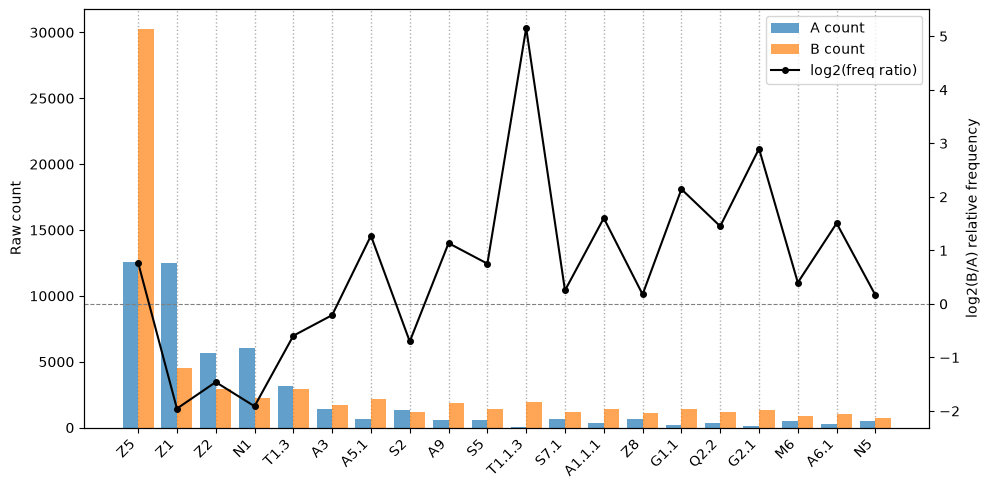

In [22]:
plot_count_and_ratio(a=reference_usas_counter, b=target_usas_counter, sort_by="total", min_count=5)
plt.show()

A different plot that could be more meaningful is to sort by the highest values of the `log2 ratio` for the `target` corpus thus finding the tags that are relatively much more likely to occur in the `target` corpus compared to the Wikipedia reference corpus:

>> **NOTE** `min_count` if this is 0 then tags that do not occur in the Wikipedia reference corpus but do occur slightly in the target corpus will have a very high `log 2 ratio`

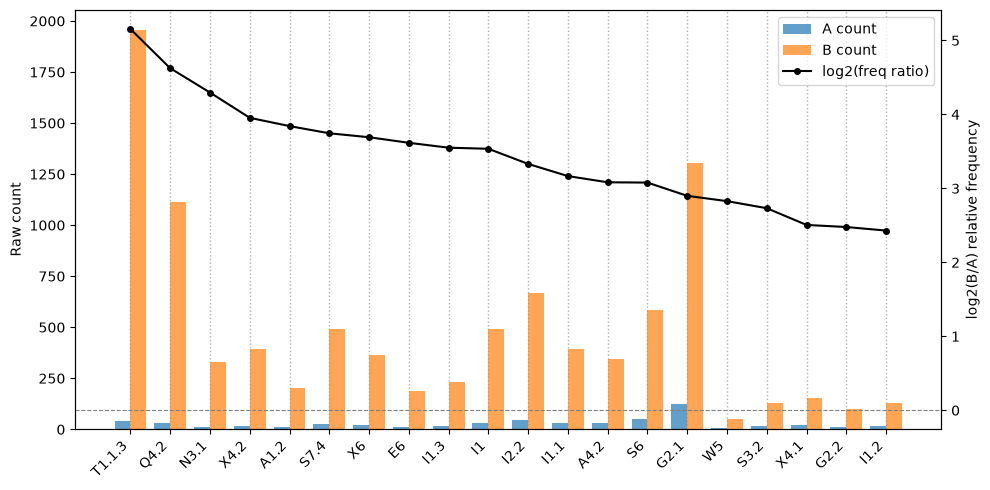

In [23]:
plot_count_and_ratio(a=reference_usas_counter, b=target_usas_counter, sort_by="ratio", min_count=5)
plt.show()

It can then be interesting to inspect what are the top most occurring word for these USAS tags in the `target` and `reference` corpus like so:

In [24]:
tag_to_inspect = "H5"
top_n_most_common = 5

reference_words = reference_usas_token_counter[tag_to_inspect].most_common(top_n_most_common)

target_words = target_usas_token_counter[tag_to_inspect].most_common(top_n_most_common)

print(f"Top {top_n_most_common} most common words for {tag_to_inspect!r} USAS tag:")
print("-"*40)
for reference_word, target_word in zip(reference_words, target_words):
    print(f"Reference word: {reference_word[0]} Count: {reference_word[1]:,}")
    print(f"Target word: {target_word[0]} Count: {target_word[1]:,}")
    print()

Top 5 most common words for 'H5' USAS tag:
----------------------------------------
Reference word: seat Count: 54
Target word: seat Count: 5

Reference word: seats Count: 10
Target word: table Count: 3

Reference word: Table Count: 2
Target word: seats Count: 1

Reference word: table Count: 2
Target word: counter Count: 1



## Exploring the Tagged data - through the keyness metric


Similar to plots in the last section we can explore the data through a metric called `keyness`. As the name suggests it is a way to find which semantically tags are "key" whereby they are used more in one corpus than the other corpus, in our case if it is used more in the `target` than the Wikipedia reference, to do this we are going to calculate the [log-likelihood](https://ucrel.lancs.ac.uk/llwizard.html) (see [Rayson, P. and Garside, R. (2000)](https://ucrel.lancs.ac.uk/people/paul/publications/rg_acl2000.pdf) on the use of comparing corpora using log-likelihood with the USAS semantic tags) of each USAS tag to get the USAS tags keyness value. A higher keyness value means the difference in frequency between the two corpora is less likely to be due to chance; significance is judged against critical values (e.g. 3.84, 6.63, 10.83 for p < 0.05, 0.01, 0.001).

Log-likelihood is unsigned, so it tells us *that* a tag differs but not *which* corpus it favours. To recover the direction we compare the tag's relative frequency in each corpus; whichever is higher is the corpus the tag is more characteristic of.


> **Note** `keyness` can be applied to different linguistics units other than USAS tags, e.g. tokens or POS tags.

To make it easier to calculate the keyness value we are going to use Pandas, of which we are going to install that now:



In [25]:
! pip install pandas

Then we are going to manipulate the USAS tag counter for the `target` and Wikipedia reference corpora into a Pandas Dataframe like so:

In [26]:
import pandas

all_usas_tags_in_corpora = set(reference_usas_counter.keys()) | set(target_usas_counter.keys())
pandas_df_dict_data = {
    "target": [],
    "wikipedia": [],
    "USAS Tag": []
}
for usas_tag in all_usas_tags_in_corpora:
    pandas_df_dict_data["target"].append(target_usas_counter.get(usas_tag, 0))
    pandas_df_dict_data["wikipedia"].append(reference_usas_counter.get(usas_tag, 0))
    pandas_df_dict_data["USAS Tag"].append(usas_tag)

usas_tag_df = pandas.DataFrame(pandas_df_dict_data)
usas_tag_df

,target,wikipedia,USAS Tag
0,0,31,H3
1,446,89,Q2.1
2,33,56,Q4
3,231,14,I1.3
4,12,9,X3.2
...,...,...,...
202,5,51,S2.1
203,573,245,Z3
204,31,18,S3.1
205,38,45,K4


In the DataFrame, `usas_tag_df`, we can see the occurrences of each USAS Tag in both the `target` and Wikipedia reference corpora.

Below we will apply the keyness metric to the DataFrame as well as calculate the relative frequency of the USAS tags in each corpus:



In [27]:
import math

def keyness(a: int, b: int, c: int, d: int) -> float:
    """
    Log-likelihood (G²) keyness statistic for a word/tag across two corpora.

    Computes log-likelihood ratio for a single term/tag. It compares the observed counts
    against the counts expected if the term were equally frequent (in relative
    terms) in both corpora; a larger value means a larger departure from that
    null expectation, in either direction.

    The four inputs form the usual 2x2 contingency table:

                      observed    corpus total
        corpus 1        a             c
        corpus 2        b             d

    Expected frequencies under the null hypothesis of equal relative frequency
    are E1 = c * (a + b) / (c + d) and E2 = d * (a + b) / (c + d), and the
    statistic is G2 = 2 * (a*ln(a/E1) + b*ln(b/E2)).

    Parameters
    ----------
    a : int
        Observed frequency of the term in corpus 1 (the target corpus).
    b : int
        Observed frequency of the term in corpus 2 (the reference corpus).
    c : int
        Total number of tokens (or tags) in corpus 1.
    d : int
        Total number of tokens (or tags) in corpus 2.

    Returns
    -------
    float
        The log-likelihood G² statistic. 0 indicates the term has identical
        relative frequency in both corpora; larger values indicate greater
        divergence. The statistic is unsigned — it does not by itself say which
        corpus the term is more frequent in (compare a/c with b/d to recover the
        direction), and it is approximately chi-square distributed with one
        degree of freedom, so values above ~3.84, 6.63, and 10.83 correspond
        roughly to p < 0.05, 0.01, and 0.001.
    """
    E1 = c * (a + b) / (c + d)
    E2 = d * (a + b) / (c + d)
    ll = 0.0
    if a > 0:
        ll += a * math.log(a / E1)
    if b > 0:
        ll += b * math.log(b / E2)
    return 2 * ll

reference_total = usas_tag_df['wikipedia'].sum()
target_total = usas_tag_df['target'].sum()

#under_over = {True: 'Over', False: 'Under'}

usas_tag_df["keyness"] = usas_tag_df.apply(lambda x: keyness(x["target"], x["wikipedia"], target_total, reference_total), axis=1)
usas_tag_df["target (relative)"] = usas_tag_df.apply(lambda x: x["target"] / target_total, axis=1)
usas_tag_df["wikipedia (relative)"] = usas_tag_df.apply(lambda x: x["wikipedia"] / reference_total, axis=1)
#comparison["use"] = comparison.apply(lambda x: under_over[x["Nile"] > x["Danube"]], axis=1)
usas_tag_df

,target,wikipedia,USAS Tag,keyness,target (relative),wikipedia (relative)
0,0,31,H3,54.501690,0.000000,0.000491
1,446,89,Q2.1,153.413017,0.005019,0.001411
2,33,56,Q4,16.491289,0.000371,0.000888
3,231,14,I1.3,165.122796,0.002600,0.000222
4,12,9,X3.2,0.015480,0.000135,0.000143
...,...,...,...,...,...,...
202,5,51,S2.1,61.329670,0.000056,0.000808
203,573,245,Z3,46.803638,0.006448,0.003884
204,31,18,S3.1,0.467594,0.000349,0.000285
205,38,45,K4,5.413392,0.000428,0.000713


We can now filter the entries in the DataFrame to keep only those that have a keyness value greater than `keyness_threshold` so that we can find significant USAS tags:

In [28]:
keyness_threshold = 3.84 # p < 0.05

significant_usas_tag_df = usas_tag_df[usas_tag_df['keyness'] >= keyness_threshold].copy()
significant_usas_tag_df

,target,wikipedia,USAS Tag,keyness,target (relative),wikipedia (relative)
0,0,31,H3,54.501690,0.000000,0.000491
1,446,89,Q2.1,153.413017,0.005019,0.001411
2,33,56,Q4,16.491289,0.000371,0.000888
3,231,14,I1.3,165.122796,0.002600,0.000222
5,108,132,S2.2,17.636019,0.001215,0.002093
...,...,...,...,...,...,...
200,31,4,F2,15.414924,0.000349,0.000063
201,72,26,X5.2,9.565703,0.000810,0.000412
202,5,51,S2.1,61.329670,0.000056,0.000808
203,573,245,Z3,46.803638,0.006448,0.003884


Now to find the USAS tags that are used significantly more in the `target` than the Wikipedia reference we need to filter further to keep only those USAS tags whereby the `target (relative)` > `wikipedia (relative)`:

In [29]:
target_significant_usas_tag_df = significant_usas_tag_df[significant_usas_tag_df['target (relative)'] > significant_usas_tag_df['wikipedia (relative)']]
# Sort by keyness
target_significant_usas_tag_df.sort_values(by='keyness', ascending=False)

,target,wikipedia,USAS Tag,keyness,target (relative),wikipedia (relative)
168,30261,12588,Z5,2707.631831,0.340555,0.199553
109,1956,39,T1.1.3,1782.968185,0.022013,0.000618
196,1112,32,Q4.2,957.305686,0.012514,0.000507
42,1303,124,G2.1,773.193733,0.014664,0.001966
145,1388,223,G1.1,585.679380,0.015620,0.003535
...,...,...,...,...,...,...
60,35,11,S1.2.5,6.283128,0.000394,0.000174
63,10,1,S1.2.6,5.784916,0.000113,0.000016
65,20,5,A1.9,5.228055,0.000225,0.000079
84,103,51,F4,4.589599,0.001159,0.000808


We can now see all the USAS tags that appear significantly more in the `target` than the Wikipedia reference with a confidence of p < 0.05, sorted by keyness value.

We can as well generate a word cloud of these significant USAS tags whereby the text size is based of it's keyness value like so:

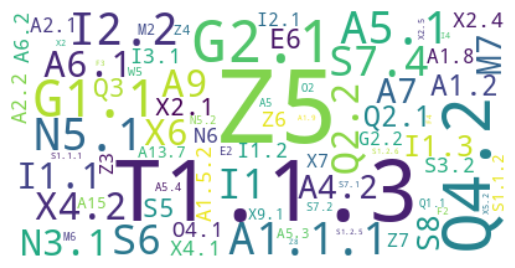

In [30]:
! pip install wordcloud
from wordcloud import WordCloud

word_cloud_usas_tag_keyness = dict(zip(target_significant_usas_tag_df['USAS Tag'].to_list(),
                                                               target_significant_usas_tag_df['keyness'].to_list()))
wordcloud = WordCloud(background_color="white").generate_from_frequencies(word_cloud_usas_tag_keyness)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

## USAS tagger can be useful for filtering a corpus

If you have a large dataset like Wikipedia or Reddit you could use the USAS tagger an initial filtration pass. For instance if you are interested in health/medical texts then you could filter for documents or sentences with at least one health related USAS token (`B2`, or `B3` tag), for finance you could use any of the `I` tags, etc. To see full descriptions and examples of tokens within those tags see [INTRODUCTION TO THE USAS CATEGORY SYSTEM guide.](https://ucrel.lancs.ac.uk/usas/usas_guide.pdf)

You might prefer to do a finer grained filtering of the data and select only texts that contain a minimum percentage of tokens with appropriate USAS tag(s).

This filtering can be useful for finding relevant data for annotation purposes or Large Language Model training.

Below we are going to show how you can filter the Wikipedia dataset for articles that might be health/medical related by creating a function `text_filter_by_usas_tags` whereby this function will return `True` if the text given to it contains more than a `threshold` fraction of tokens or MWEs that is from a set of USAS tags, `usas_tags_of_interest`, that you have given as an argument to the function, we use the `nlp` argument to tag the given text.

The code sample below will print the first 5 texts from Wikipedia whereby at least 2% (0.02) of the tokens in the text are tagged with health/medical tags (`B2` or `B3`):

**NOTE this can take a while, at least 10 minutes as many of the Wikipedia texts are not health related, if it is taking to long interrupt the process and move on to the next section of the notebook**

In [54]:
from usas_validator.utils import load_usas_mapper

def text_filter_by_usas_tags(text: str, nlp: spacy.Language, usas_tags_of_interest: set[str], valid_usas_tags: set[str], threshold: float) -> bool:
    """
    Determine whether a text contains a large proportion of a set of USAS semantic tags.

    Tags every token and MWE in ``text`` using ``get_usas_tags`` (with no POS
    or USAS tag filtering applied), then computes the proportion of
    observations whose tag falls in ``usas_tags_of_interest``. Returns
    ``True`` if that proportion strictly exceeds ``threshold``.

    Intended as a dataset filter

    Args:
        text: The raw input string to evaluate.
        nlp: A spaCy ``Language`` pipeline with the PyMUSAS semantic tagger
            attached. Passed directly to ``get_usas_tags``.
        usas_tags_of_interest: USAS tag strings to count as matching.
        valid_usas_tags: The recognised USAS tag set used to filter raw
            tagger output. Passed directly to ``get_usas_tags``.
        threshold: A value in ``[0.0, 1.0)``. The text is considered to
            exceed the threshold when
            ``tags_of_interest / total_tags > threshold``.

    Returns:
        ``True`` if the proportion of matching tags strictly exceeds
        ``threshold``, ``False`` otherwise.

    Raises:
        ZeroDivisionError: If ``text`` yields no tagged observations after
            filtering (e.g. the text is empty or all tokens are discarded
            by ``valid_usas_tags``).
    """
    pos_tags_to_ignore = set()
    usas_tags_to_ignore = set()

    tags_of_interest_count = 0
    total_tag_count = 0
    for token_or_mwe, usas_tag in get_usas_tags(nlp, text, pos_tags_to_ignore, usas_tags_to_ignore, valid_usas_tags):
        if usas_tag in usas_tags_of_interest:
            tags_of_interest_count += 1
        total_tag_count += 1
    if tags_of_interest_count / total_tag_count > threshold:
        return True
    return False

usas_tags_of_interest = set({"B2", "B3"})
usas_tag_description_mapper = load_usas_mapper(None, None)
valid_usas_tags = set(usas_tag_description_mapper.keys())

sample_count = 0
number_of_samples_filtered = 0
for sample in get_wikipedia_dataset_iterable(LANGUAGE):
    if text_filter_by_usas_tags(sample, nlp, usas_tags_of_interest, valid_usas_tags, 0.04):
        sample_count += 1
        print(f'Filter sample: {sample_count}\n{"---"*10}\n{sample}\n{"---"*10}')
        
    if sample_count > 4:
        break
    number_of_samples_filtered += 1
print()
print(f"Number of samples filtered out: {number_of_samples_filtered:,}")

Filter sample: 1
------------------------------
# (+)-Naloxone
(+)-Naloxone (dextro-naloxone) is a drug which is the opposite enantiomer of the opioid antagonist drug (−)-naloxone. Unlike (−)-naloxone, (+)-naloxone has no significant affinity for opioid receptors, but instead has been discovered to act as a selective antagonist of Toll-like receptor 4. This receptor is involved in immune system responses, and activation of TLR4 induces glial activation and release of inflammatory mediators such as TNF-α and Interleukin-1.

## Relation with opioids
Both active and inactive enantiomers of various opioid analgesic drugs including morphine, meperidine, fentanyl, methadone and buprenorphine, as well as some otherwise inactive metabolites like morphine-3-glucuronide, have been found to act as agonists of TLR4, and chronic use of these drugs consequently causes constant low-level release of TNF-α and IL-1β as well as other downstream effects. This is thought to be involved in various adverse 

As is likely to be the case the texts are somewhat related but it is likely to have returned a few False-Positive of which these can probably be removed through increasing the `threshold` value but in doing so you are likely to increase the False-Negatives, this type of filtering is very quick and can be used as an initial first coarse grained filtering step before using another more powerful filter based tool that is likely to be costly to run over the entire dataset, e.g. a LLM.

**For English** it took 10 minutes to find 5 health related texts but it filtered out 2,135 Wikipedia texts that it believes are not health related. If you wanted the texts to be processed faster you could distribute the processing over many computers, of which as PyMUSAS, especially the Rule Based model, does not require much compute resources the computers that are required to be distributed across do not need to be very powerful, e.g. a single CPU with 4-8GB of RAM. Furthermore, the Rule Based model from PyMUSAS on a more powerful machine can be ran in parallel across multiple processes (multi-processing in Python).

## Hybrid Tagger -- Extension work

Follow the [guide within the PyMUSAS documentation](https://ucrel.github.io/pymusas/usage/how_to/tag_text_with/hybrid_tagger) and see how it compares to the Rule Based approach that was used earlier in the notebook:

> **Note** to start with follow the guide exactly using `English` as the tagging language and then try to re-configure it for your language of choice (currently the Hybrid tagger only supports the following languages: `Chinese`, `Danish`, `Dutch`, `English`, `Finnish`, `French`, `Indonesian`, `Italian`, `Portuguese`, `Spanish`, `Welsh`, and `Malay`)

**Let us know if you need any help**

In [55]:
# Hybrid tagger code

## Neural Tagger -- Extension work

Like the Hybrid tagger, [follow the guide within the PyMUSAS documentation](https://ucrel.github.io/pymusas/usage/how_to/tag_text_with/neural_tagger) and see how it compared to the Rule Based approach that was used earlier in the notebook:

> **Note** the Multilingual neural tagger does support up to 1,811 languages

**Let us know if you need any help**



In [56]:
# Neural tagger code